In [44]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import warnings

class Portofolio():
    def __init__(self, w = None, returns=None   ):
        if w is None:
            raise RuntimeError("Provide portfolio weights for class Portfolio()")
        if returns is None: 
            raise RuntimeError("Provide returns for class Portfolio()")
        if len(w) != returns.shape[1]:
            raise RuntimeError(f"portfolio weights size {len(w)} mismatch asset size {returns.shape[1]}")
        w = np.array(w, dtype=float) 
        pass

        s = np.sum(w)
        if not np.isclose(s,1.0):
            warnings.warn(f"Weights {w} sum = {s}. Normalizing to 1 : {w/s}")
            w /= s
        self.weights = w 

        self.rets    = returns.copy()
        self.asset_names = list(self.rets.columns)

    def portfolio_returns(self):
        rp = self.rets[self.asset_names].to_numpy() @ self.weights
        return pd.Series(rp, index=self.rets.index, name='portfolio return')

    def equity_curve(self, s=1.0):
        rp = self.portfolio_returns()
        y  = s * (1.0 + rp).cumprod()
        y.name = "Equity"
        return y 
        

    
    def optimize(self):
        pass 

returns = pd.read_csv("toy_returns.csv",index_col=0)
port =  Portofolio(w=[0.1,0.5,0.7],returns=returns)
port1 = Portofolio(w=[1.0,0.0,0.0],returns=returns)
port2 = Portofolio(w=[0.0,1.0,0.0],returns=returns)
port3 = Portofolio(w=[0.0,0.0,1.0],returns=returns)



C:\Users\User\AppData\Local\Temp\ipykernel_9620\1510297822.py:19: UserWarning: Weights [0.1 0.5 0.7] sum = 1.2999999999999998. Normalizing to 1 : [0.07692308 0.38461538 0.53846154]
  warnings.warn(f"Weights {w} sum = {s}. Normalizing to 1 : {w/s}")


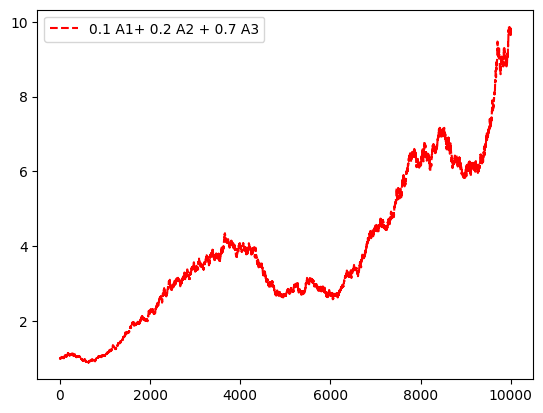

In [45]:
y = port.equity_curve()
 
fig, ax = plt.subplots()

ax.plot(y, color='r', ls='--', label='0.1 A1+ 0.2 A2 + 0.7 A3')

ax.legend()
plt.show()
